In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
ds = pd.read_excel("CleanedDataset.xlsx")

In [3]:
print("Shape dataset:",ds.shape)
print("\nColumn names dataset:",ds.columns)
print("\nNull values dataset:\n",ds.isnull().sum())

Shape dataset: (60, 18)

Column names dataset: Index(['Unnamed: 0', 'customer_id', 'first_name', 'gender', 'age', 'city',
       'province', 'signup_date', 'membership_tier', 'purchase_count',
       'avg_order_value', 'total_spending', 'last_purchase_days',
       'payment_method', 'device', 'discount_used', 'returned_items',
       'satisfaction_score'],
      dtype='str')

Null values dataset:
 Unnamed: 0            0
customer_id           0
first_name            0
gender                0
age                   0
city                  0
province              0
signup_date           0
membership_tier       0
purchase_count        0
avg_order_value       0
total_spending        0
last_purchase_days    0
payment_method        0
device                0
discount_used         0
returned_items        0
satisfaction_score    0
dtype: int64


In [4]:
ds.head()

,Unnamed: 0,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
0,0,1001,Reza,M,19,Karaj,Alborz,2025-02-19,VIP,17,121.53,2066.01,16,Card,Android,Yes,3,5
1,1,1002,Sina,M,53,Tehran,Tehran,2022-08-19,Gold,12,326.47,3917.64,3,Card,Web,No,5,3
2,2,1003,Parsa,M,31,Shiraz,Fars,2023-06-20,Gold,21,59.46,1248.66,22,Online Wallet,iPhone,Yes,6,1
3,3,1004,Sina,M,58,Mashhad,Khorasan,2021-11-08,Gold,23,266.15,6121.45,40,Card,Android,No,4,4
4,4,1005,Kimia,F,28,Isfahan,Isfahan,2021-10-21,Silver,23,169.54,3899.42,273,Online Wallet,Android,Yes,7,4


In [5]:
ds.drop(columns="Unnamed: 0",inplace=True)
ds.head()

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
0,1001,Reza,M,19,Karaj,Alborz,2025-02-19,VIP,17,121.53,2066.01,16,Card,Android,Yes,3,5
1,1002,Sina,M,53,Tehran,Tehran,2022-08-19,Gold,12,326.47,3917.64,3,Card,Web,No,5,3
2,1003,Parsa,M,31,Shiraz,Fars,2023-06-20,Gold,21,59.46,1248.66,22,Online Wallet,iPhone,Yes,6,1
3,1004,Sina,M,58,Mashhad,Khorasan,2021-11-08,Gold,23,266.15,6121.45,40,Card,Android,No,4,4
4,1005,Kimia,F,28,Isfahan,Isfahan,2021-10-21,Silver,23,169.54,3899.42,273,Online Wallet,Android,Yes,7,4


In [6]:
print("Shape dataset Before removing duplicates:",ds.shape)
ds = ds.drop_duplicates()
print("Shape dataset After removing duplicates:",ds.shape)

Shape dataset Before removing duplicates: (60, 17)
Shape dataset After removing duplicates: (60, 17)


In [7]:
required_columns = [
 "customer_id", "first_name", "gender", "age", "city", "province",
 "signup_date", "membership_tier", "purchase_count", "avg_order_value",
 "total_spending", "last_purchase_days", "payment_method", "device",
 "discount_used", "returned_items", "satisfaction_score"
]

missing_columns = [col for col in required_columns if col not in ds.columns]
if missing_columns:
    raise ValueError(f"These columns are not in the data set :{missing_columns}")

print("\nDataset INFO:\n",ds.info())

In [8]:
ds['signup_date'] = pd.to_datetime(ds['signup_date'],errors='coerce')

numeric_columns = [
 "age", "purchase_count", "avg_order_value", "total_spending",
 "last_purchase_days", "returned_items", "satisfaction_score"
]
for col in numeric_columns:
    ds[col] = pd.to_numeric(ds[col], errors="coerce")


text_columns = [
 "first_name", "gender", "city", "province", "membership_tier",
 "payment_method", "device", "discount_used"
]
for col in text_columns:
    ds[col] = ds[col].astype("string").str.strip()


In [9]:
display(ds.head())

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
0,1001,Reza,M,19,Karaj,Alborz,2025-02-19,VIP,17,121.53,2066.01,16,Card,Android,Yes,3,5
1,1002,Sina,M,53,Tehran,Tehran,2022-08-19,Gold,12,326.47,3917.64,3,Card,Web,No,5,3
2,1003,Parsa,M,31,Shiraz,Fars,2023-06-20,Gold,21,59.46,1248.66,22,Online Wallet,iPhone,Yes,6,1
3,1004,Sina,M,58,Mashhad,Khorasan,2021-11-08,Gold,23,266.15,6121.45,40,Card,Android,No,4,4
4,1005,Kimia,F,28,Isfahan,Isfahan,2021-10-21,Silver,23,169.54,3899.42,273,Online Wallet,Android,Yes,7,4


In [10]:
ds.info()

<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   customer_id         60 non-null     int64         
 1   first_name          60 non-null     string        
 2   gender              60 non-null     string        
 3   age                 60 non-null     int64         
 4   city                60 non-null     string        
 5   province            60 non-null     string        
 6   signup_date         60 non-null     datetime64[us]
 7   membership_tier     60 non-null     string        
 8   purchase_count      60 non-null     int64         
 9   avg_order_value     60 non-null     float64       
 10  total_spending      60 non-null     float64       
 11  last_purchase_days  60 non-null     int64         
 12  payment_method      60 non-null     string        
 13  device              60 non-null     string        
 14  discoun

In [11]:
print("Unique Ages:", sorted(ds.age.unique(), reverse=True))

Unique Ages: [np.int64(65), np.int64(64), np.int64(63), np.int64(62), np.int64(61), np.int64(60), np.int64(59), np.int64(58), np.int64(57), np.int64(54), np.int64(53), np.int64(51), np.int64(50), np.int64(49), np.int64(48), np.int64(47), np.int64(45), np.int64(43), np.int64(42), np.int64(41), np.int64(39), np.int64(37), np.int64(35), np.int64(34), np.int64(32), np.int64(31), np.int64(30), np.int64(28), np.int64(26), np.int64(25), np.int64(23), np.int64(22), np.int64(19)]


In [12]:
print("Unique Ages:", np.sort(ds.age.unique())[::-1])

Unique Ages: [65 64 63 62 61 60 59 58 57 54 53 51 50 49 48 47 45 43 42 41 39 37 35 34
 32 31 30 28 26 25 23 22 19]


In [13]:
bins = [0, 24, 34, 44, 54, 64, np.inf]
labels = ["Under 25", "25-34", "35-44", "45-54", "55-64", "more than 65"]

ds["age_group"] = pd.cut(ds["age"], bins=bins, labels=labels, include_lowest=True)
ds["age_group"].value_counts()

age_group
55-64           16
45-54           15
25-34           11
35-44           10
Under 25         7
more than 65     1
Name: count, dtype: int64

In [14]:
profile_summary={
"Total Customers":ds['customer_id'].nunique(),
"Average Age":ds['age'].mean(),
"Median Age":ds['age'].median(),
"Most Common Gender":ds['gender'].mode().iloc[0],
"Most Common Membership":ds['membership_tier'].mode().iloc[0],
"Most Common Device":ds['device'].mode().iloc[0],
"Most Common Payment Method":ds['payment_method'].mode().iloc[0]
}

profile_table = pd.Series(profile_summary,name='Value')
profile_table

Total Customers                          60
Average Age                            43.7
Median Age                             45.0
Most Common Gender                        M
Most Common Membership                 Gold
Most Common Device                  Android
Most Common Payment Method    Online Wallet
Name: Value, dtype: object

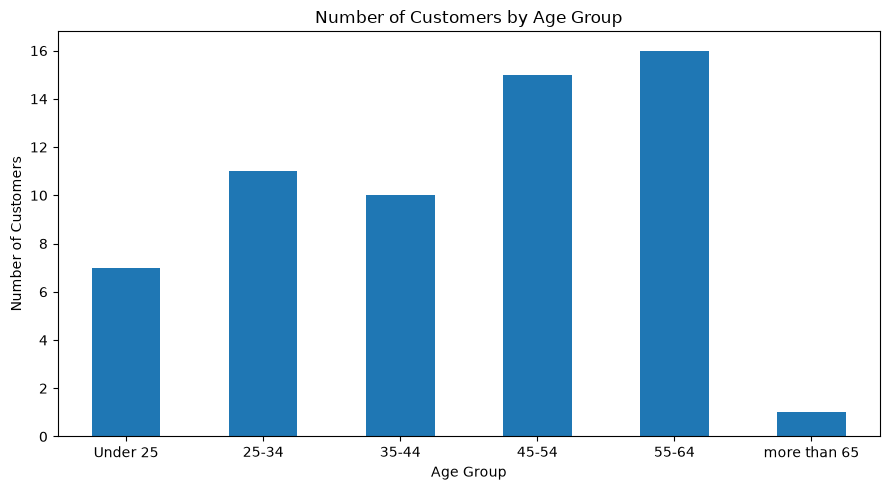

In [15]:
age_counts = ds["age_group"].value_counts(sort=False)
age_counts.plot(kind="bar", figsize=(9, 5))
plt.title("Number of Customers by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

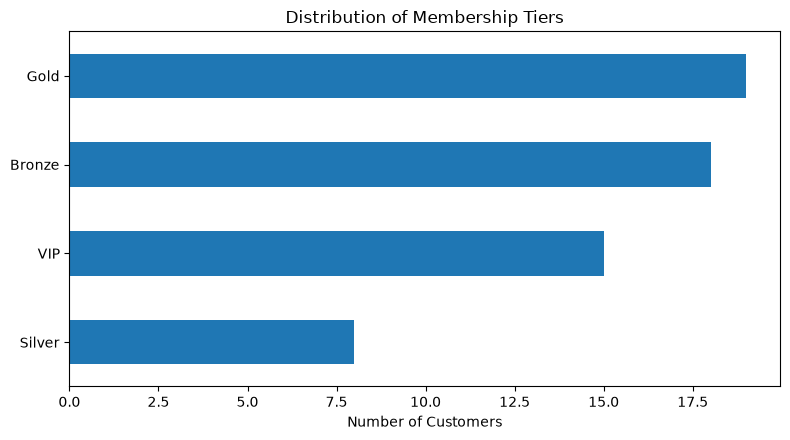

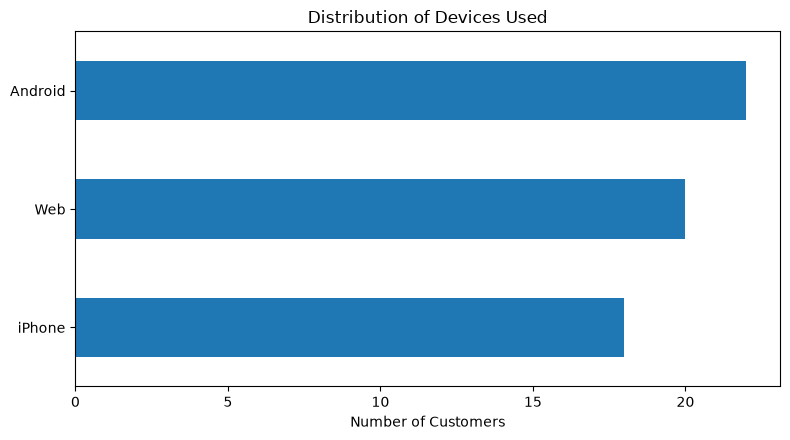

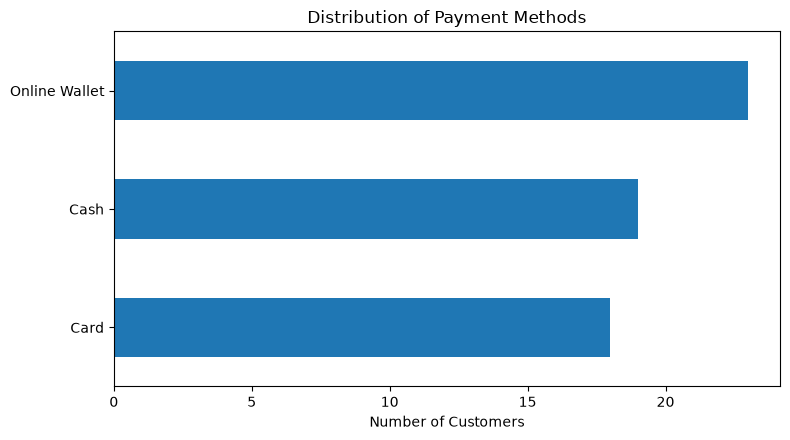

In [16]:
columns_to_plot = [
    ("membership_tier", "Distribution of Membership Tiers"),
    ("device", "Distribution of Devices Used"),
    ("payment_method", "Distribution of Payment Methods"),
]

for column, title in columns_to_plot:
    counts = ds[column].value_counts().sort_values(ascending=True)
    counts.plot(kind="barh", figsize=(8, 4.5))
    plt.title(title)
    plt.xlabel("Number of Customers")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

The store's customer base of 60 individuals skews toward an older demographic, with a median age of 45 and the largest single age group (55-64) accounting for 16 customers — roughly a quarter of the total. Male customers form the majority, and Gold is the most common membership tier, suggesting a loyal, higher-engagement customer base rather than mostly new or entry-level shoppers. Android is the dominant device, and Online Wallet is the leading payment method, pointing to a mobile-first, digitally comfortable audience. Together, this profile suggests the dominant customer is a middle-aged to older male, Gold-tier member who shops via Android using digital wallets — a segment marketing campaigns should prioritize in messaging and channel choice, while still watching whether a smaller but higher-value segment (e.g., younger or Platinum-tier customers) warrants separate attention in later questions.

In [17]:
city_summary = ds.groupby(['province', 'city']).agg(
    customer_count=('customer_id', 'nunique'),
    total_income=('total_spending', 'sum'),
    avg_purchase_count=('purchase_count', 'mean'),
    avg_order_value=('avg_order_value', 'mean'),
    avg_satisfaction=('satisfaction_score', 'mean')
).reset_index()

city_summary

,province,city,customer_count,total_income,avg_purchase_count,avg_order_value,avg_satisfaction
0,Alborz,Karaj,7,26189.81,16.000000,211.440000,2.857143
1,East Azerbaijan,Tabriz,12,38188.56,16.166667,238.901667,3.000000
2,Fars,Shiraz,6,20715.92,16.333333,180.983333,2.000000
3,Gilan,Rasht,5,17116.44,17.400000,241.554000,2.600000
4,Isfahan,Isfahan,5,21975.32,19.800000,212.680000,4.400000
5,Khorasan,Mashhad,11,43197.58,22.636364,210.508182,2.909091
6,Khuzestan,Ahvaz,8,27377.75,15.500000,216.531250,3.500000
7,Tehran,Tehran,6,15161.29,17.166667,172.930000,2.666667


In [18]:
city_summary = city_summary[city_summary["customer_count"] >= 3]

top_cities = city_summary.nlargest(10, "total_income").sort_values("total_income")
top_cities

,province,city,customer_count,total_income,avg_purchase_count,avg_order_value,avg_satisfaction
7,Tehran,Tehran,6,15161.29,17.166667,172.930000,2.666667
3,Gilan,Rasht,5,17116.44,17.400000,241.554000,2.600000
2,Fars,Shiraz,6,20715.92,16.333333,180.983333,2.000000
4,Isfahan,Isfahan,5,21975.32,19.800000,212.680000,4.400000
0,Alborz,Karaj,7,26189.81,16.000000,211.440000,2.857143
6,Khuzestan,Ahvaz,8,27377.75,15.500000,216.531250,3.500000
1,East Azerbaijan,Tabriz,12,38188.56,16.166667,238.901667,3.000000
5,Khorasan,Mashhad,11,43197.58,22.636364,210.508182,2.909091


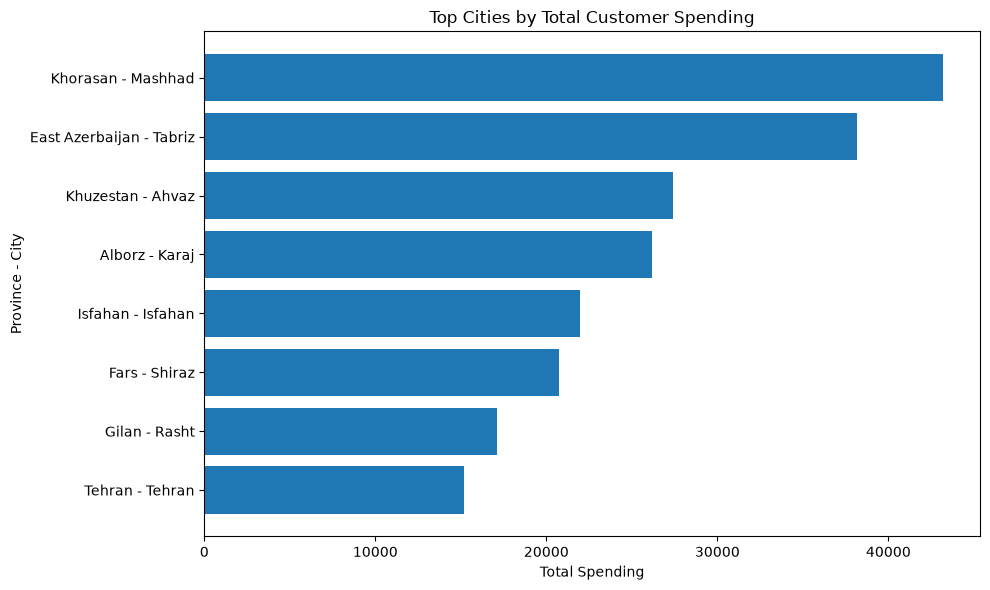

In [19]:
labels = top_cities["province"] + " - " + top_cities["city"]

plt.figure(figsize=(10, 6))
plt.barh(labels, top_cities["total_income"])
plt.title("Top Cities by Total Customer Spending")
plt.xlabel("Total Spending")
plt.ylabel("Province - City")
plt.tight_layout()
plt.show()

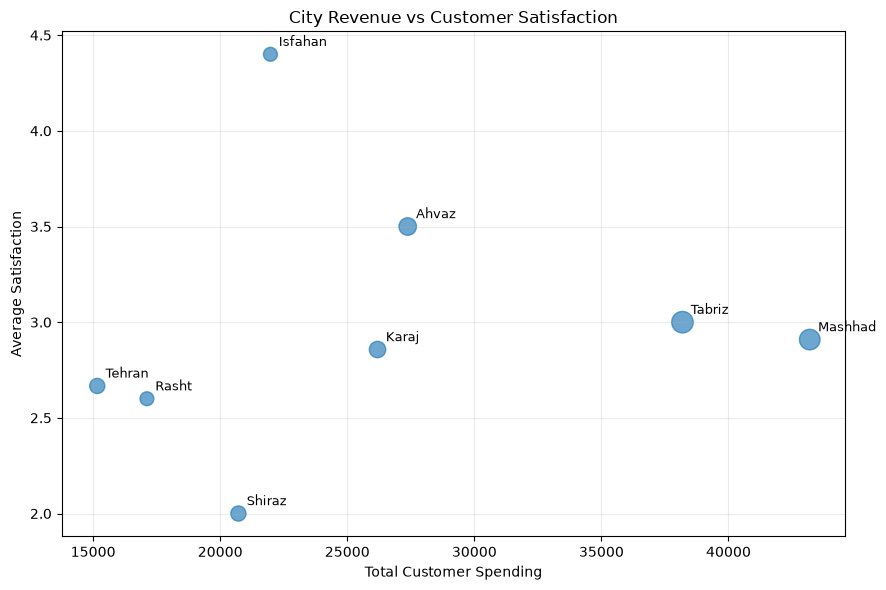

In [20]:
plt.figure(figsize=(9, 6))
plt.scatter(
    city_summary["total_income"],
    city_summary["avg_satisfaction"],
    s=city_summary["customer_count"] * 20,
    alpha=0.65
)

for _, row in city_summary.iterrows():
    plt.annotate(
        row["city"],
        (row["total_income"], row["avg_satisfaction"]),
        textcoords="offset points",
        xytext=(6, 6),
        fontsize=9
    )

plt.title("City Revenue vs Customer Satisfaction")
plt.xlabel("Total Customer Spending")
plt.ylabel("Average Satisfaction")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [21]:
recommended_city = city_summary.sort_values(
    ["total_income", "avg_satisfaction", "customer_count"],
    ascending=[False, False, False]
).head()

recommended_city

,province,city,customer_count,total_income,avg_purchase_count,avg_order_value,avg_satisfaction
5,Khorasan,Mashhad,11,43197.58,22.636364,210.508182,2.909091
1,East Azerbaijan,Tabriz,12,38188.56,16.166667,238.901667,3.000000
6,Khuzestan,Ahvaz,8,27377.75,15.500000,216.531250,3.500000
0,Alborz,Karaj,7,26189.81,16.000000,211.440000,2.857143
4,Isfahan,Isfahan,5,21975.32,19.800000,212.680000,4.400000


Recommended city: Mashhad
- Mashhad has the highest total revenue (43,198) and the second-highest customer count (11), showing a large and financially active market. However, its average satisfaction score (2.91) is below the group average — a risk signal that this revenue may be fragile. Before scaling ad spend here, we recommend running a customer satisfaction survey to identify the root cause of dissatisfaction, since this dataset can only show the pattern, not the reason behind it.

Alternative city: Isfahan
- Isfahan has the highest satisfaction score by a wide margin (4.40) but the smallest customer base (5 customers) and moderate revenue. This suggests a small but healthy market. Rather than risking budget on an underperforming-satisfaction market, a customer-centric marketing approach here could grow a proven, loyal customer base.

Conclusion: The final choice depends on business priorities. Mashhad offers immediate scale but carries retention risk; Isfahan offers a safer, smaller growth opportunity with strong customer sentiment. This recommendation is based on three metrics — total revenue, average satisfaction, and customer count — rather than revenue alone.

In [22]:
columns_to_normalize = ["total_spending", "purchase_count", "satisfaction_score"]

for column in columns_to_normalize:
    min_value = ds[column].min()
    max_value = ds[column].max()
    ds[column + "_score"] = (ds[column] - min_value) / (max_value - min_value)

In [23]:
min_days = ds['last_purchase_days'].min()
max_days = ds['last_purchase_days'].max()
ds['recency_score'] = 1 - ((ds['last_purchase_days'] - min_days) / (max_days - min_days)) 

In [24]:
ds.head()

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,...,payment_method,device,discount_used,returned_items,satisfaction_score,age_group,total_spending_score,purchase_count_score,satisfaction_score_score,recency_score
0,1001,Reza,M,19,Karaj,Alborz,2025-02-19,VIP,17,121.53,...,Card,Android,Yes,3,5,Under 25,0.136267,0.470588,1.00,0.964088
1,1002,Sina,M,53,Tehran,Tehran,2022-08-19,Gold,12,326.47,...,Card,Web,No,5,3,45-54,0.266416,0.323529,0.50,1.000000
2,1003,Parsa,M,31,Shiraz,Fars,2023-06-20,Gold,21,59.46,...,Online Wallet,iPhone,Yes,6,1,25-34,0.078816,0.588235,0.00,0.947514
3,1004,Sina,M,58,Mashhad,Khorasan,2021-11-08,Gold,23,266.15,...,Card,Android,No,4,4,55-64,0.421319,0.647059,0.75,0.897790
4,1005,Kimia,F,28,Isfahan,Isfahan,2021-10-21,Silver,23,169.54,...,Online Wallet,Android,Yes,7,4,25-34,0.265135,0.647059,0.75,0.254144


In [25]:
ds["loyalty_score"] = (
    0.35 * ds["total_spending_score"]
    + 0.30 * ds["purchase_count_score"]
    + 0.20 * ds["recency_score"]
    + 0.15 * ds["satisfaction_score_score"]
)

top_loyal_customers = ds.nlargest(10, "loyalty_score")[[
    "customer_id", "first_name", "membership_tier", "purchase_count",
    "total_spending", "last_purchase_days", "satisfaction_score",
    "loyalty_score"
]]

top_loyal_customers

,customer_id,first_name,membership_tier,purchase_count,total_spending,last_purchase_days,satisfaction_score,loyalty_score
56,1057,Maryam,Bronze,31,13532.74,82,4,0.863347
43,1044,Mina,Gold,33,14354.34,165,2,0.780350
58,1059,Ali,Gold,31,8898.55,224,5,0.708388
8,1009,Kimia,Silver,34,11615.42,232,2,0.684777
3,1004,Sina,Gold,23,6121.45,40,4,0.633637
11,1012,Arash,Gold,27,11731.50,224,2,0.630288
32,1033,Neda,VIP,24,5521.20,112,5,0.625415
13,1014,Reza,VIP,31,3353.89,97,4,0.604649
22,1023,Ali,Bronze,31,3851.44,170,4,0.576558
16,1017,Parsa,VIP,30,3239.40,135,4,0.572014


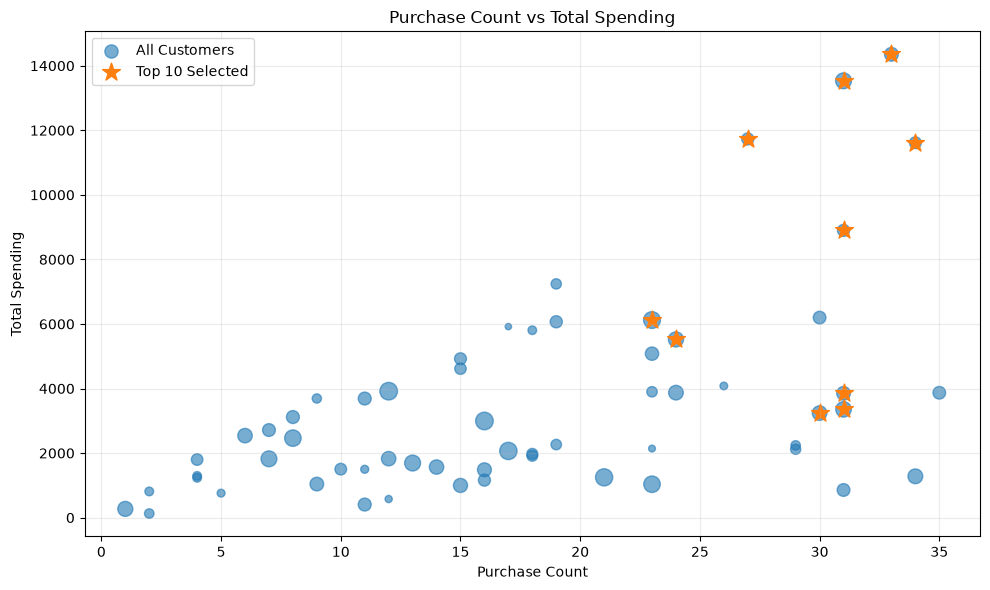

In [26]:
plt.figure(figsize=(10, 6))

plt.scatter(
    ds["purchase_count"],
    ds["total_spending"],
    s=(ds["recency_score"] + 0.15) * 140,
    alpha=0.6,
    label="All Customers"
)

plt.scatter(
    top_loyal_customers["purchase_count"],
    top_loyal_customers["total_spending"],
    s=180,
    marker="*",
    label="Top 10 Selected"
)

plt.title("Purchase Count vs Total Spending")
plt.xlabel("Purchase Count")
plt.ylabel("Total Spending")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

Why these weights?
- Total spending was weighted highest (0.35) since it directly reflects financial value to the business. Purchase count (0.30) captures repeat engagement, which is a stronger loyalty signal than a single large order. Recency (0.20) ensures customers who have recently disengaged aren't over-prioritized, even if their historical spending is high. Satisfaction (0.15) was weighted lowest because, while important, it's more subjective and doesn't directly measure financial contribution.

Key observation: 
- The top-ranked customer (Maryam, ID 1057) holds a Bronze membership tier — not VIP or Gold — yet ranks #1 by behavior-based loyalty score. This shows that membership tier alone is not a reliable proxy for actual loyalty; several Gold and VIP customers rank lower due to less frequent purchasing or longer inactivity. This mismatch is worth flagging to management, since the current tier system may be misaligned with actual customer value.

In [27]:
spending_threshold = ds["total_spending"].quantile(0.75)
purchase_threshold = ds["purchase_count"].median()
inactivity_threshold = ds["last_purchase_days"].quantile(0.75)

ds["at_risk"] = (
    (ds["total_spending"] >= spending_threshold) &
    (ds["purchase_count"] >= purchase_threshold) &
    (ds["last_purchase_days"] >= inactivity_threshold)
)

at_risk_customers = ds.loc[ds["at_risk"], [
    "customer_id", "first_name", "membership_tier", "purchase_count",
    "total_spending", "last_purchase_days", "satisfaction_score"
]].sort_values(
    ["total_spending", "last_purchase_days"],
    ascending=[False, False]
)

print("Number of at-risk customers:", len(at_risk_customers))
at_risk_customers

Number of at-risk customers: 3


,customer_id,first_name,membership_tier,purchase_count,total_spending,last_purchase_days,satisfaction_score
9,1010,Arash,Silver,19,7241.47,276,1
34,1035,Arash,Bronze,17,5918.21,365,3
52,1053,Sina,Gold,18,5805.54,320,1


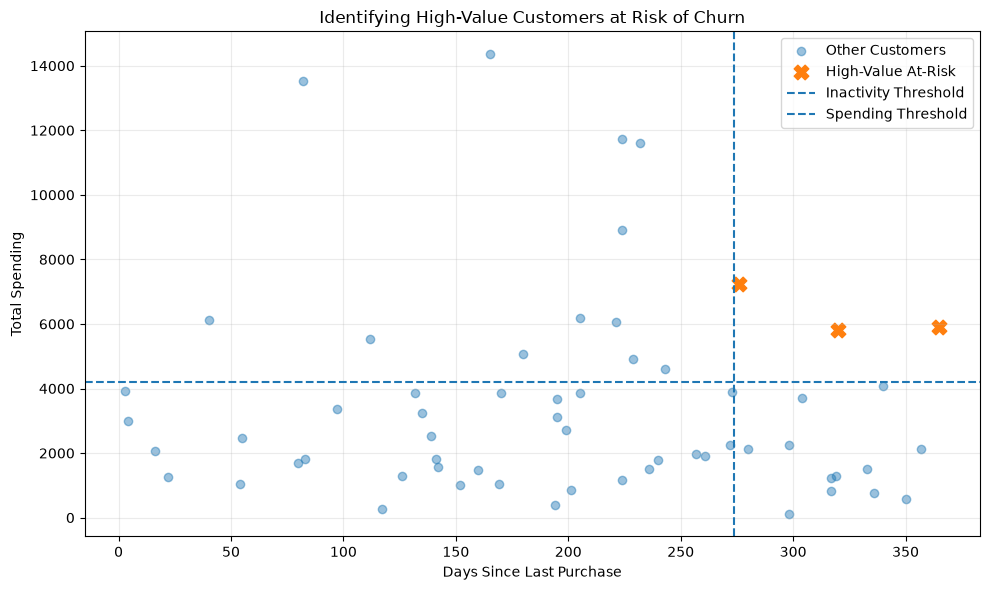

In [28]:
plt.figure(figsize=(10, 6))

plt.scatter(
    ds.loc[~ds["at_risk"], "last_purchase_days"],
    ds.loc[~ds["at_risk"], "total_spending"],
    alpha=0.45,
    label="Other Customers"
)

plt.scatter(
    ds.loc[ds["at_risk"], "last_purchase_days"],
    ds.loc[ds["at_risk"], "total_spending"],
    marker="X",
    s=110,
    label="High-Value At-Risk"
)

plt.axvline(inactivity_threshold, linestyle="--", label="Inactivity Threshold")
plt.axhline(spending_threshold, linestyle="--", label="Spending Threshold")

plt.title("Identifying High-Value Customers at Risk of Churn")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Total Spending")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

Definition of "high-value customer at risk": A customer is flagged as at-risk if they simultaneously fall in the top 25% of total spending, have an above-median purchase count (indicating they were repeat buyers, not one-time purchasers), and fall in the top 25% of days since their last purchase. This three-condition rule ensures we're not flagging customers who are simply low-spenders with long gaps, but genuinely high-value customers who have gone unusually quiet.

Findings: 3 customers meet this definition. Two of them (Arash - ID 1010, Sina - ID 1053) have very low satisfaction scores (1/5), suggesting dissatisfaction likely drove their disengagement — these customers should be prioritized for direct outreach with a service-recovery approach (e.g., a personal apology, a support check-in, or a compensatory offer). The third (Arash - ID 1035) has a moderate satisfaction score (3/5) despite a full year of inactivity, suggesting a different cause — possibly reduced need or switching to a competitor rather than dissatisfaction — and may respond better to a re-engagement incentive (discount, new product highlight) rather than a service-recovery message.

Limitation: This dataset only tracks days since last purchase, not full purchase history, so we cannot confirm definitive churn — only elevated risk based on current inactivity.

In [29]:
summary_by_discount = ds.groupby("discount_used").agg(
    customer_count=("customer_id", "nunique"),
    avg_total_spending=("total_spending", "mean"),
    avg_purchase_count=("purchase_count", "mean"),
    avg_order_value=("avg_order_value", "mean"),
    avg_returned_items=("returned_items", "mean"),
    avg_satisfaction=("satisfaction_score", "mean")
).reset_index()

summary_by_discount

,discount_used,customer_count,avg_total_spending,avg_purchase_count,avg_order_value,avg_returned_items,avg_satisfaction
0,No,34,3837.466765,17.588235,220.700588,4.264706,2.764706
1,Yes,26,3055.723077,18.000000,203.291154,4.076923,3.269231


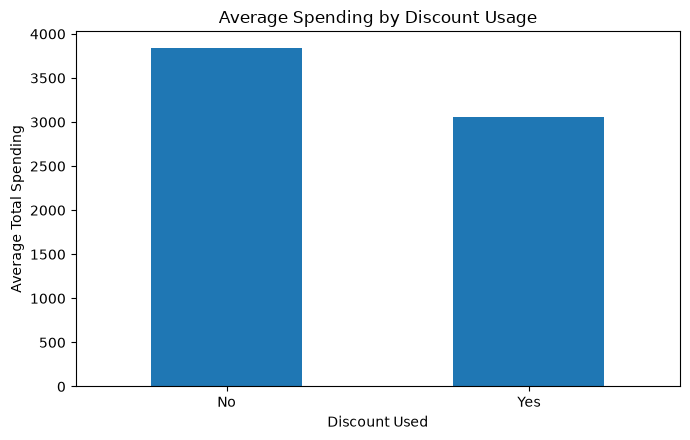

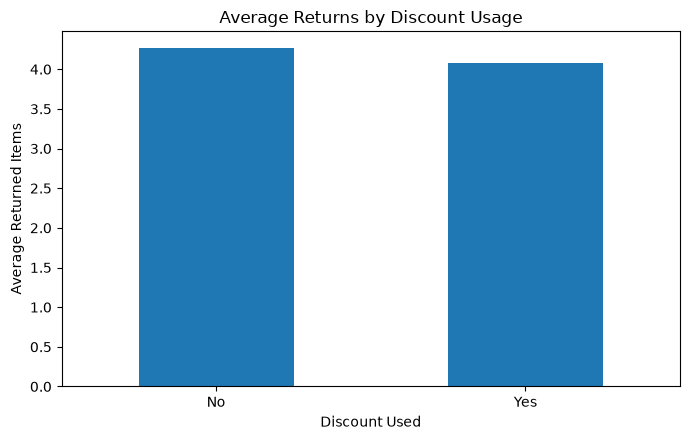

In [30]:
metrics = [
    ("avg_total_spending", "Average Spending by Discount Usage", "Average Total Spending"),
    ("avg_returned_items", "Average Returns by Discount Usage", "Average Returned Items"),
]

for metric, title, ylabel in metrics:
    summary_by_discount.plot(
        x="discount_used", y=metric, kind="bar", legend=False, figsize=(7, 4.5)
    )
    plt.title(title)
    plt.xlabel("Discount Used")
    plt.ylabel(ylabel)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

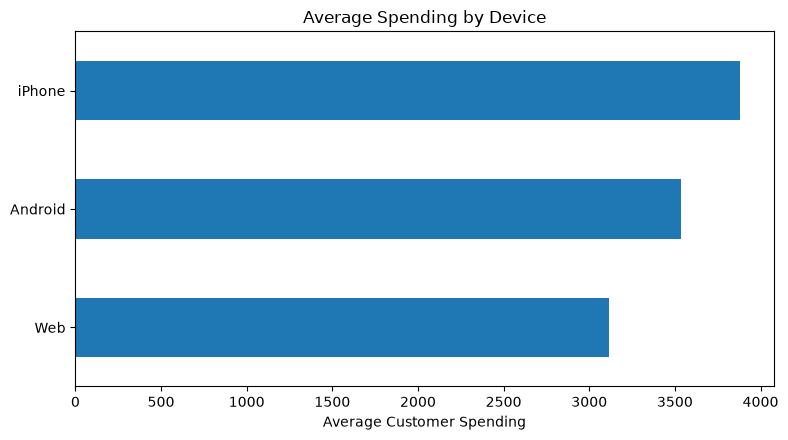

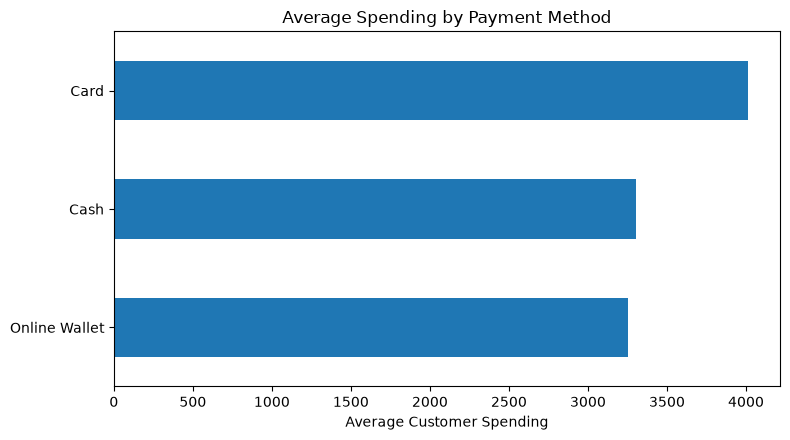

In [31]:
factors = [
    ("device", "Average Spending by Device"),
    ("payment_method", "Average Spending by Payment Method"),
]

for factor, title in factors:
    factor_summary = (
        ds.groupby(factor)["total_spending"]
        .agg(["count", "mean"])
        .query("count >= 3")
        .sort_values("mean", ascending=True)
    )
    
    factor_summary["mean"].plot(kind="barh", figsize=(8, 4.5))
    plt.title(title)
    plt.xlabel("Average Customer Spending")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

Discount usage: Customers who did not use a discount actually spent more on average (3,837 vs 3,056) but reported lower satisfaction (2.76 vs 3.27). Return rates were similar between the two groups (4.26 vs 4.08). This does not indicate discounts reduce spending — it's more likely that pre-existing customer segments differ in both discount-seeking behavior and satisfaction, and this dataset cannot isolate the cause.

Device: iPhone users have the highest average spending, followed by Android, then Web — despite Android being the most common device overall. This shows that the most popular device is not necessarily the highest-value one.

Payment method: Card users spend the most on average, ahead of Cash and Online Wallet — even though Online Wallet was the most common payment method overall.

Important note: This analysis is descriptive only and does not establish a causal relationship between discount use, device, payment method, and customer behavior.

In [32]:
kpi_summary = pd.Series({
    "Total Customers": ds["customer_id"].nunique(),
    "Total Revenue": ds["total_spending"].sum(),
    "Average Spending per Customer": ds["total_spending"].mean(),
    "Average Purchase Count": ds["purchase_count"].mean(),
    "Average Satisfaction": ds["satisfaction_score"].mean(),
    "Total Returned Items": ds["returned_items"].sum()
}, name="Value")

kpi_summary

Total Customers                      60.000000
Total Revenue                    209922.670000
Average Spending per Customer      3498.711167
Average Purchase Count               17.766667
Average Satisfaction                  2.983333
Total Returned Items                251.000000
Name: Value, dtype: float64

Recommendation 1
KPI: Regional Revenue & Satisfaction
Action: Prioritize ad budget for Mashhad while launching a satisfaction-recovery survey there; simultaneously run a smaller customer-centric campaign in Isfahan to protect and grow its already-loyal base.
Evidence: Mashhad generates the highest revenue (43,198) but has below-average satisfaction (2.91); Isfahan has the highest satisfaction (4.40) with a smaller but healthy customer base.

Recommendation 2
KPI: High-Value Customer Retention
Action: Launch a targeted win-back campaign for the 3 identified high-value at-risk customers — a service-recovery approach (personal outreach, compensation) for the two with low satisfaction scores, and a re-engagement incentive for the one with moderate satisfaction.
Evidence: 3 customers are in the top 25% of spending and inactivity, with 2 of them reporting satisfaction scores of 1/5 — a clear churn risk signal.

Recommendation 3
KPI: Discount Program Effectiveness
Action: Re-evaluate the discount program's targeting — rather than assuming discounts drive more spending, investigate whether discounts are being used mainly by lower-spending or already-dissatisfied segments, since the current data shows an unexpected pattern.
Evidence: Customers who did not use a discount spent more on average (3,837 vs 3,056) despite lower satisfaction (2.76 vs 3.27) — this correlation, not causation, warrants further investigation before scaling the discount program.

In [33]:
with pd.ExcelWriter("customer_analytics_results.xlsx") as writer:
    kpi_summary.to_excel(writer, sheet_name="KPI")
    city_summary.to_excel(writer, sheet_name="City Analysis", index=False)
    top_loyal_customers.to_excel(writer, sheet_name="Top Loyal Customers", index=False)
    at_risk_customers.to_excel(writer, sheet_name="At Risk Customers", index=False)
    summary_by_discount.to_excel(writer, sheet_name="Discount Analysis", index=False)

print("File saved: customer_analytics_results.xlsx")

File saved: customer_analytics_results.xlsx
